# Stochastic Unit Commitment (Energy Market Application)

## Problem Description

A power generator must decide **day-ahead** how much electricity to commit to produce, facing uncertain demand and renewable generation. This is a classic **two-stage stochastic program**:

- **First stage (here-and-now):** Commit generation capacity $x$ at cost $c_1$
- **Second stage (wait-and-see):** After observing demand $d$ and renewable output $w$:
  - Use committed capacity or buy from spot market at price $c_s$
  - Penalized for unmet demand at cost $c_p$

$$\min_{x} \; c_1^T x + \mathbb{E}_{\\xi}\left[Q(x, \\xi)\right]$$

where $Q(x, \\xi)$ is the recourse (second-stage) cost.

---

## Concepts
1. **Two-stage stochastic LP**
2. **Scenario generation** (from historical data)
3. **Value of Stochastic Solution (VSS)**
4. **Expected Value of Perfect Information (EVPI)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Stochastic Unit Commitment Problem")
print("=" * 40)

Stochastic Unit Commitment Problem


## 1. Problem Setup

We have 3 generators with different costs and capacities, and uncertain demand.

In [2]:
# Generator parameters
n_gen = 3
gen_names = ['Coal', 'Gas', 'Peaker']
gen_capacity = np.array([100, 80, 50])   # MW
gen_cost = np.array([30, 50, 100])        # $/MWh (commitment cost)
spot_price = 150                          # $/MWh (spot market cost)
penalty_cost = 500                        # $/MWh (load shedding penalty)

# Demand scenarios (uncertain)
n_scenarios = 100
demand_mean = 180  # MW
demand_std = 30    # MW

# Wind generation scenarios (uncertain)
wind_mean = 40     # MW
wind_std = 20      # MW

# Generate scenarios
rng = np.random.default_rng(42)
demand_scenarios = rng.normal(demand_mean, demand_std, n_scenarios)
demand_scenarios = np.clip(demand_scenarios, 100, 280)
wind_scenarios = rng.normal(wind_mean, wind_std, n_scenarios)
wind_scenarios = np.clip(wind_scenarios, 0, 80)

# Net demand (demand - wind)
net_demand = demand_scenarios - wind_scenarios

print(f"Generators: {list(zip(gen_names, gen_capacity, gen_cost))}")
print(f"Spot market price: ${spot_price}/MWh")
print(f"Penalty cost: ${penalty_cost}/MWh")
print(f"\nNet demand stats: mean={net_demand.mean():.1f}, std={net_demand.std():.1f}")
print(f"Range: [{net_demand.min():.1f}, {net_demand.max():.1f}] MW")

Generators: [('Coal', np.int64(100), np.int64(30)), ('Gas', np.int64(80), np.int64(50)), ('Peaker', np.int64(50), np.int64(100))]
Spot market price: $150/MWh
Penalty cost: $500/MWh

Net demand stats: mean=138.9, std=28.6
Range: [75.3, 212.0] MW


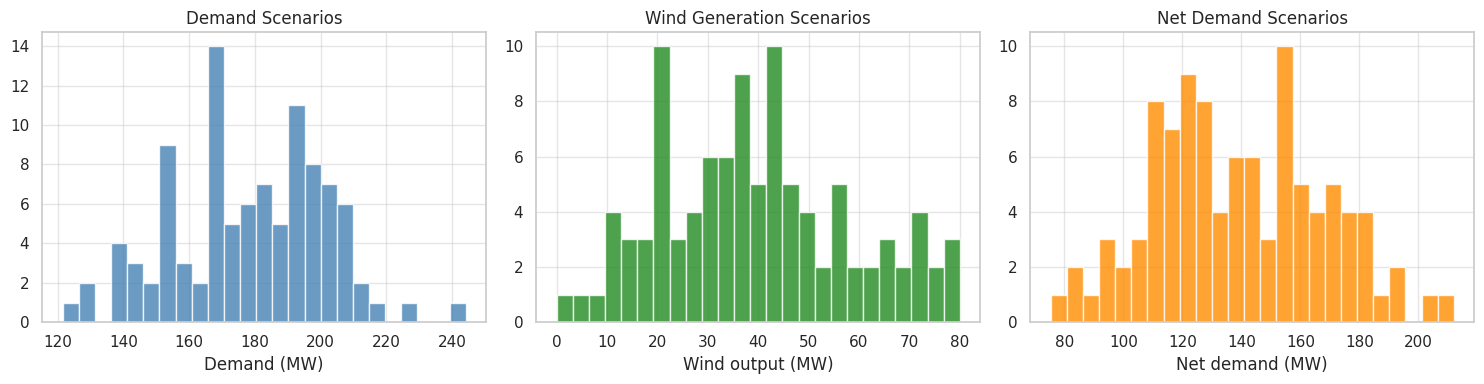

In [3]:
# Visualize scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(demand_scenarios, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Demand Scenarios', fontsize=12)
axes[0].set_xlabel('Demand (MW)')

axes[1].hist(wind_scenarios, bins=25, color='forestgreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Wind Generation Scenarios', fontsize=12)
axes[1].set_xlabel('Wind output (MW)')

axes[2].hist(net_demand, bins=25, color='darkorange', edgecolor='white', alpha=0.8)
axes[2].set_title('Net Demand Scenarios', fontsize=12)
axes[2].set_xlabel('Net demand (MW)')

plt.tight_layout()
plt.show()

## 2. Two-Stage Stochastic Program

**First stage:** Choose committed generation $x_g \in [0, \text{cap}_g]$

**Second stage (for each scenario $s$):**
- $y_s$ = spot market purchase
- $z_s$ = unmet demand (load shedding)

$$\min \sum_g c_g x_g + \frac{1}{S}\sum_s \left(c_s \cdot y_s + c_p \cdot z_s\right)$$
$$\text{s.t.} \quad \sum_g x_g + y_s + z_s \geq d_s \quad \forall s$$
$$0 \leq x_g \leq \text{cap}_g, \quad y_s \geq 0, \quad z_s \geq 0$$

In [4]:
def solve_stochastic_uc(net_demand_scenarios, gen_capacity, gen_cost, 
                        spot_price, penalty_cost):
    """Solve the two-stage stochastic unit commitment problem."""
    n_gen = len(gen_capacity)
    n_scen = len(net_demand_scenarios)
    
    prob = pulp.LpProblem("Stochastic_UC", pulp.LpMinimize)
    
    # First-stage variables: generation commitment
    x = [pulp.LpVariable(f"x_{g}", lowBound=0, upBound=gen_capacity[g]) 
         for g in range(n_gen)]
    
    # Second-stage variables
    y = [pulp.LpVariable(f"y_{s}", lowBound=0) for s in range(n_scen)]
    z = [pulp.LpVariable(f"z_{s}", lowBound=0) for s in range(n_scen)]
    
    # Objective
    first_stage_cost = pulp.lpSum(gen_cost[g] * x[g] for g in range(n_gen))
    second_stage_cost = (1.0 / n_scen) * pulp.lpSum(
        spot_price * y[s] + penalty_cost * z[s] for s in range(n_scen)
    )
    prob += first_stage_cost + second_stage_cost
    
    # Constraints: meet demand in each scenario
    for s in range(n_scen):
        prob += (pulp.lpSum(x[g] for g in range(n_gen)) + y[s] + z[s] 
                >= net_demand_scenarios[s])
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    
    x_val = np.array([pulp.value(x[g]) for g in range(n_gen)])
    obj_val = pulp.value(prob.objective)
    y_val = np.array([pulp.value(y[s]) for s in range(n_scen)])
    z_val = np.array([pulp.value(z[s]) for s in range(n_scen)])
    
    return obj_val, x_val, y_val, z_val

# Solve stochastic program
sp_obj, sp_x, sp_y, sp_z = solve_stochastic_uc(
    net_demand, gen_capacity, gen_cost, spot_price, penalty_cost
)

print("STOCHASTIC SOLUTION (SP)")
print("=" * 40)
print(f"Optimal cost: ${sp_obj:,.2f}")
print(f"\nCommitted generation:")
for g in range(n_gen):
    print(f"  {gen_names[g]}: {sp_x[g]:.1f} MW (capacity: {gen_capacity[g]} MW)")
print(f"  Total committed: {sp_x.sum():.1f} MW")
print(f"\nAverage spot purchase: {sp_y.mean():.1f} MW")
print(f"Average load shedding: {sp_z.mean():.2f} MW")

STOCHASTIC SOLUTION (SP)
Optimal cost: $6,560.96

Committed generation:
  Coal: 100.0 MW (capacity: 100 MW)
  Gas: 53.9 MW (capacity: 80 MW)
  Peaker: 0.0 MW (capacity: 50 MW)
  Total committed: 153.9 MW

Average spot purchase: 5.8 MW
Average load shedding: 0.00 MW


## 3. Deterministic Solution (Expected Value Problem)

The **EV solution** replaces all scenarios with their mean. This ignores uncertainty.

In [5]:
# Expected Value (EV) solution: use mean demand
mean_net_demand = np.array([net_demand.mean()])
ev_obj, ev_x, _, _ = solve_stochastic_uc(
    mean_net_demand, gen_capacity, gen_cost, spot_price, penalty_cost
)

print("DETERMINISTIC (EV) SOLUTION")
print("=" * 40)
print(f"Committed generation (using mean demand = {net_demand.mean():.1f} MW):")
for g in range(n_gen):
    print(f"  {gen_names[g]}: {ev_x[g]:.1f} MW")
print(f"  Total committed: {ev_x.sum():.1f} MW")

# Evaluate EV solution on all scenarios (EEV)
def evaluate_first_stage(x_fixed, scenarios, gen_cost, spot_price, penalty_cost):
    """Evaluate a fixed first-stage decision across scenarios."""
    total_committed = x_fixed.sum()
    first_cost = np.dot(gen_cost, x_fixed)
    recourse_costs = []
    for d in scenarios:
        shortfall = max(d - total_committed, 0)
        spot_cost = spot_price * shortfall
        recourse_costs.append(spot_cost)
    return first_cost + np.mean(recourse_costs)

eev = evaluate_first_stage(ev_x, net_demand, gen_cost, spot_price, penalty_cost)
print(f"\nEEV (EV solution evaluated on scenarios): ${eev:,.2f}")

DETERMINISTIC (EV) SOLUTION
Committed generation (using mean demand = 138.9 MW):
  Coal: 100.0 MW
  Gas: 38.9 MW
  Peaker: 0.0 MW
  Total committed: 138.9 MW

EEV (EV solution evaluated on scenarios): $6,736.26


## 4. Value of the Stochastic Solution (VSS)

$$\text{VSS} = \text{EEV} - \text{SP}$$

The VSS quantifies **the cost of ignoring uncertainty**. A high VSS means stochastic modeling is valuable.

In [6]:
# Value of the Stochastic Solution
VSS = eev - sp_obj

# EVPI: solve anticipative (perfect information)
evpi_costs = []
for s in range(len(net_demand)):
    obj_s, _, _, _ = solve_stochastic_uc(
        np.array([net_demand[s]]), gen_capacity, gen_cost, spot_price, penalty_cost
    )
    evpi_costs.append(obj_s)

WS = np.mean(evpi_costs)  # Wait-and-See solution
EVPI = sp_obj - WS

print("VALUE OF INFORMATION ANALYSIS")
print("=" * 50)
print(f"  WS  (Wait-and-See / Perfect Info):  ${WS:>10,.2f}")
print(f"  SP  (Stochastic Program):           ${sp_obj:>10,.2f}")
print(f"  EEV (Deterministic solution):        ${eev:>10,.2f}")
print(f"")
print(f"  EVPI = SP - WS = ${EVPI:>8,.2f}  (value of perfect information)")
print(f"  VSS  = EEV - SP = ${VSS:>8,.2f}  (value of stochastic solution)")
print(f"")
print(f"  WS ≤ SP ≤ EEV: {WS:.2f} ≤ {sp_obj:.2f} ≤ {eev:.2f} ✓")

VALUE OF INFORMATION ANALYSIS
  WS  (Wait-and-See / Perfect Info):  $  5,007.49
  SP  (Stochastic Program):           $  6,560.96
  EEV (Deterministic solution):        $  6,736.26

  EVPI = SP - WS = $1,553.47  (value of perfect information)
  VSS  = EEV - SP = $  175.30  (value of stochastic solution)

  WS ≤ SP ≤ EEV: 5007.49 ≤ 6560.96 ≤ 6736.26 ✓


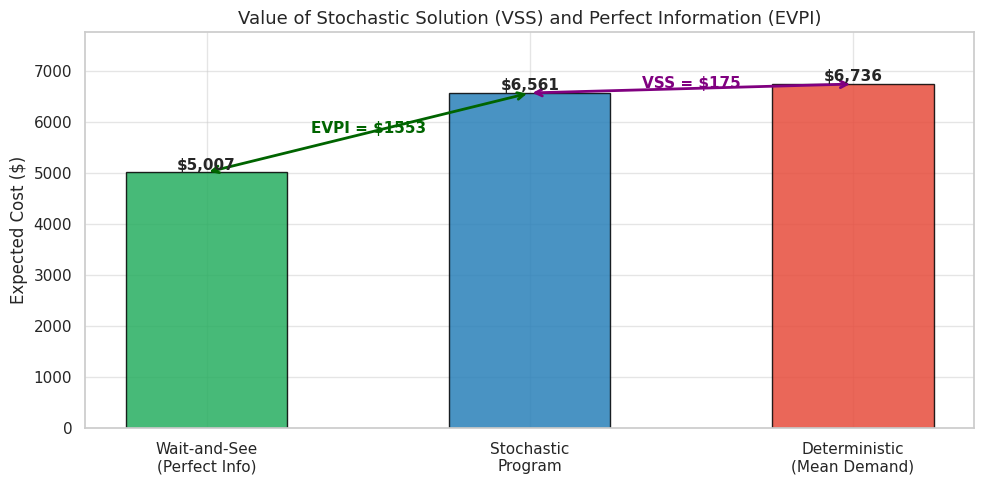

In [7]:
# Visualization of VSS and EVPI
fig, ax = plt.subplots(figsize=(10, 5))

methods = ['Wait-and-See\n(Perfect Info)', 'Stochastic\nProgram', 'Deterministic\n(Mean Demand)']
costs = [WS, sp_obj, eev]
colors = ['#27ae60', '#2980b9', '#e74c3c']

bars = ax.bar(methods, costs, color=colors, edgecolor='black', alpha=0.85, width=0.5)

# Annotate
ax.annotate('', xy=(1, sp_obj), xytext=(2, eev),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(1.5, (sp_obj + eev) / 2, f'VSS = ${VSS:.0f}', ha='center', fontsize=11,
        color='purple', fontweight='bold')

ax.annotate('', xy=(0, WS), xytext=(1, sp_obj),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))
ax.text(0.5, (WS + sp_obj) / 2, f'EVPI = ${EVPI:.0f}', ha='center', fontsize=11,
        color='darkgreen', fontweight='bold')

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2, cost + 50, f'${cost:,.0f}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Expected Cost ($)', fontsize=12)
ax.set_title('Value of Stochastic Solution (VSS) and Perfect Information (EVPI)', fontsize=13)
ax.set_ylim(0, max(costs) * 1.15)
plt.tight_layout()
plt.show()

## 5. Scenario Sensitivity Analysis

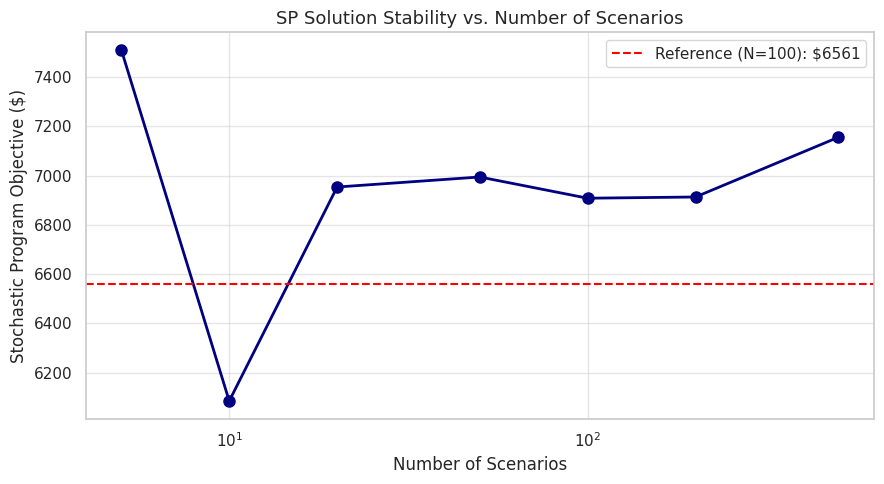

In [8]:
# How does solution quality change with number of scenarios?
n_scen_range = [5, 10, 20, 50, 100, 200, 500]
sp_values = []

for n_s in n_scen_range:
    scen = rng.normal(demand_mean, demand_std, n_s) - rng.normal(wind_mean, wind_std, n_s)
    scen = np.clip(scen, 50, 280)
    obj, _, _, _ = solve_stochastic_uc(scen, gen_capacity, gen_cost, spot_price, penalty_cost)
    sp_values.append(obj)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_scen_range, sp_values, 'o-', color='navy', linewidth=2, markersize=8)
ax.axhline(sp_obj, color='red', linestyle='--', label=f'Reference (N={n_scenarios}): ${sp_obj:.0f}')
ax.set_xlabel('Number of Scenarios', fontsize=12)
ax.set_ylabel('Stochastic Program Objective ($)', fontsize=12)
ax.set_title('SP Solution Stability vs. Number of Scenarios', fontsize=13)
ax.legend(fontsize=11)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| WS (Perfect Info) | Lower bound | Best possible with clairvoyance |
| SP (Stochastic) | Optimal under uncertainty | Best achievable non-anticipative |
| EEV (Deterministic) | Upper bound | Cost of ignoring uncertainty |
| EVPI | SP - WS | Worth of perfect forecasts |
| VSS | EEV - SP | Benefit of stochastic modeling |

### Notes for Energy Markets
- Stochastic programming captures the **asymmetric costs** of over/under-commitment
- The VSS justifies investment in uncertainty modeling
- EVPI puts an upper bound on the value of better forecasts
- More scenarios → more stable solutions, but diminishing returns